# Lecture 08 – Introducción a Deep Learning
### Universidad EAFIT | 2026 - Introduccion a la IA

---

## ¿Qué es Deep Learning?

Las **redes neuronales** son modelos de Machine Learning inspirados en el cerebro humano. Aprenden patrones complejos a partir de datos ajustando millones de parámetros distribuidos en capas interconectadas.

### Deep Learning vs. Machine Learning Tradicional

En el **Machine Learning tradicional**, un experto humano diseña manualmente las features relevantes:

```
Raw Input → Feature Engineering (humano) → Features → Modelo ML → Output
```

En **Deep Learning**, la red aprende las features automáticamente desde los datos crudos:

```
Raw Input → DNN (aprende representaciones jerárquicas) → Output
```

> **La clave**: Al apilar múltiples capas, la red aprende representaciones cada vez más abstractas: de píxeles → bordes → formas → conceptos. Esto elimina la necesidad de feature engineering manual.

---

## ¿Qué construiremos en este notebook?

Implementaremos y compararemos **dos modelos** para clasificar dígitos escritos a mano (dataset MNIST):

| Modelo | Descripción | Frontera de decisión |
|--------|-------------|---------------------|
| **Regresión Logística** | Una sola capa lineal (baseline) | Lineal |
| **Red Neuronal FC** | Capa oculta + activación ReLU | No-lineal |

Al final podrás observar cómo añadir capas ocultas con activaciones no-lineales mejora significativamente la capacidad del modelo para reconocer patrones complejos.

---

---
## 0. Configuración del Entorno

Importamos las librerías necesarias y configuramos el dispositivo de cómputo.

**PyTorch** es el framework de Deep Learning que usaremos. Permite construir y entrenar redes neuronales de manera flexible usando grafos de cómputo dinámicos.

> **GPU vs CPU**: Si hay una GPU disponible (`cuda`), el entrenamiento es órdenes de magnitud más rápido. Las GPUs tienen miles de núcleos pequeños optimizados para las operaciones matriciales masivas que requieren las redes neuronales.

In [3]:
import torch                                    # Framework principal de Deep Learning
import torchvision.transforms as transforms     # Transformaciones para imágenes (normalización, etc.)
import torchvision.datasets as dsets            # Datasets estándar listos para usar (MNIST, CIFAR, etc.)
import matplotlib.pyplot as plt                 # Visualización de datos e imágenes



device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # Detectar automáticamente si hay GPU disponible; si no, usar CPU.
print(f'Dispositivo de cómputo seleccionado: {device}')# Las GPUs aceleran drásticamente el entrenamiento porque están optimizadas
# para las operaciones matriciales masivas que usan las redes neuronales.

Dispositivo de cómputo seleccionado: cpu


---
## 1. Carga del Dataset: MNIST

**MNIST** (Modified National Institute of Standards and Technology) es uno de los datasets más usados en visión por computadora. Contiene:

- **70,000 imágenes** de dígitos escritos a mano (dígitos 0–9)
- **60,000** para entrenamiento + **10,000** para prueba
- Cada imagen es de **28×28 píxeles** en escala de grises
- **10 clases**: los dígitos del 0 al 9

### Representación de una imagen como vector de features

Como vimos en clase, una imagen en escala de grises es simplemente una **matriz de píxeles**. Cada píxel tiene un valor entre 0 y 255. Para la red neuronal:
- Normalizamos los valores al rango **[0, 1]** (con `ToTensor()`)
- **Aplanamos** la imagen de 28×28 a un **vector de 784 valores** → estas son las *features de entrada* al modelo

MNIST es el punto de partida ideal: suficientemente simple para entrenar en minutos, pero suficientemente rico para ilustrar conceptos clave.

In [ ]:
# Descargamos y cargamos el dataset MNIST desde torchvision.
# transforms.ToTensor() convierte imágenes PIL (valores 0-255)
#              a tensores de PyTorch (valores flotantes 0.0-1.0) — normalización automática
train_dataset = dsets.MNIST(root='./data', train=True,  transform=transforms.ToTensor(), download=True)
test_dataset  = dsets.MNIST(root='./data', train=False, transform=transforms.ToTensor())

print(f'Muestras de entrenamiento : {len(train_dataset)}') # train=True  → 60,000 imágenes de entrenamiento
print(f'Muestras de prueba        : {len(test_dataset)}') # train=False → 10,000 imágenes de prueba (nunca vistas durante el entrenamiento)
print(f'Tamaño de una imagen      : {train_dataset[0][0].shape}  → (canales, alto, ancho)')
print(f'Tamaño de una imagen      : {train_dataset[0][0].shape}  → (canales, alto, ancho)')
print(f'Número de clases         : {len(train_dataset.classes)}  → {train_dataset.classes}')

Muestras de entrenamiento : 60000
Muestras de prueba        : 10000
Tamaño de una imagen      : torch.Size([1, 28, 28])  → (canales, alto, ancho)
Tipo de datos    : <class 'torchvision.datasets.mnist.MNIST'>  → Tensor de PyTorch
Tamaño de una imagen      : torch.Size([1, 28, 28])  → (canales, alto, ancho)
Número de clases         : 10  → ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


In [9]:
batch_size = 64  # Número de imágenes procesadas simultáneamente en cada paso de entrenamiento

# DataLoader: envuelve el dataset y permite iterarlo en mini-batches de forma eficiente.
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True) #shuffle=True en entrenamiento mezcla los datos en cada epoch para evitar que el modelo aprenda el orden de los ejemplos (reduce sesgos de orden).
test_loader  = torch.utils.data.DataLoader(dataset=test_dataset,  batch_size=batch_size, shuffle=False) #shuffle=False en prueba: los resultados deben ser reproducibles y consistentes.

print(f'Batches de entrenamiento : {len(train_loader)}  ({len(train_dataset)} imgs / {batch_size} por batch)')
print(f'Batches de prueba        : {len(test_loader)}')

Batches de entrenamiento : 938  (60000 imgs / 64 por batch)
Batches de prueba        : 157


### ¿Por qué usar DataLoader y no cargar todos los datos a la vez?

Cargar todos los datos a la vez y pasarlos completos al modelo en cada paso de
entrenamiento (**full-batch**) tiene tres problemas prácticos importantes:

#### 1. Memoria limitada
Un dataset como MNIST tiene 60,000 imágenes de 28×28. En datasets reales
(ImageNet: 1.2M imágenes de alta resolución) los datos simplemente **no caben
en la memoria RAM ni en la GPU**. El DataLoader carga solo el mini-batch que
se necesita en cada momento.

#### 2. Convergencia más lenta y frágil
Con el batch completo, los pesos se actualizan **una sola vez por epoch**
usando el gradiente exacto. Con mini-batches, los pesos se actualizan
`N / batch_size` veces por epoch. El ruido introducido por los mini-batches
actúa como regularización y ayuda al optimizador a **escapar de mínimos locales**.

| Estrategia | Actualizaciones/epoch | Memoria | Convergencia |
|-----------|----------------------|---------|-------------|
| Full-batch | 1 | Alta | Lenta, puede atascarse |
| **Mini-batch (DataLoader)** | N / batch_size | Baja | **Rápida y estable** |
| SGD puro (1 ejemplo) | N | Muy baja | Muy ruidosa |

#### 3. `shuffle` y generalización
El DataLoader mezcla los datos en cada epoch (`shuffle=True`), evitando que
el modelo aprenda el **orden** en que aparecen los ejemplos, lo que podría
introducir sesgos no deseados.

> En resumen: el DataLoader no es solo comodidad — es una pieza clave para
> entrenar redes neuronales de forma eficiente, escalable y con mejor
> generalización.


In [ ]:
# Extraemos el primer mini-batch del DataLoader para explorar la estructura de los datos.
images, labels = next(iter(train_loader))#avanza el iterador una posición y devuelve el primer batch.

print(f'Shape del batch de imágenes  : {images.shape}')   # (batch_size, canales, alto, ancho)
print(f'Shape del batch de etiquetas : {labels.shape}')   # (batch_size,)
print(f'Etiquetas (primeras 10)      : {labels[:10].tolist()}')

Shape del batch de imágenes  : torch.Size([64, 1, 28, 28])
Shape del batch de etiquetas : torch.Size([64])
Etiquetas (primeras 10)      : [4, 9, 0, 3, 9, 9, 8, 0, 1, 3]


Text(0.5, 1.02, 'Ejemplos del Dataset MNIST')

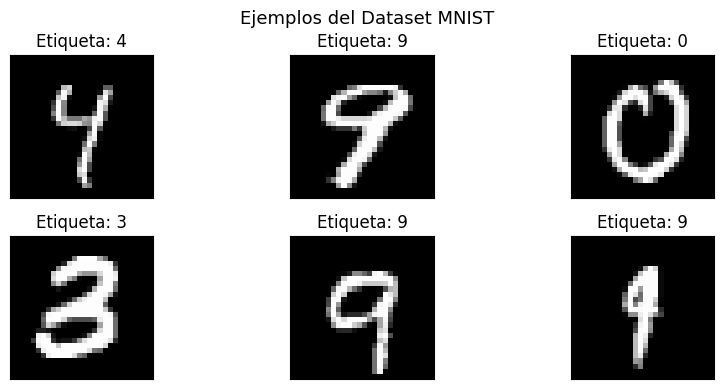

In [12]:
# Visualizamos 6 imágenes de ejemplo del batch para conocer los datos.
fig = plt.figure(figsize=(9, 4))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.tight_layout()
    plt.imshow(images[i][0], cmap='gray', interpolation='none')  # [0]: selecciona el único canal (escala de grises)
    plt.title(f'Etiqueta: {labels[i].item()}')                   # Mostramos el dígito real (ground truth)
    plt.xticks([])  # Ocultamos los ejes para mejor visualización
    plt.yticks([])
plt.suptitle('Ejemplos del Dataset MNIST', fontsize=13, y=1.02)


---
## 2. Definición de Modelos

### Revisión: Del Perceptrón a las Redes Neuronales Profundas

Como vimos en clase, el modelo más simple de clasificación multi-clase es la **Regresión Logística** con **Softmax**:

$$P(y_k \mid \mathbf{x};\, \mathbf{w}) = \frac{e^{z_k}}{\displaystyle\sum_{j=1}^{K} e^{z_j}}, \quad \text{donde } z_k = \mathbf{w}_k \cdot \mathbf{x}$$

La predicción es la clase con mayor probabilidad: $\hat{y} = \arg\max_k \; P(y_k \mid \mathbf{x})$

### El problema de los modelos lineales

La Regresión Logística solo aprende **fronteras de decisión lineales**. Para reconocer dígitos con variaciones de forma, grosor e inclinación, necesitamos mayor capacidad expresiva.

### Red Neuronal Fully-Connected (DNN)

Una **Deep Neural Network** apila múltiples capas lineales separadas por funciones de activación no-lineales:

$$z_i^{(k)} = g\!\left(\sum_j W_{ij}^{(k)} \cdot z_j^{(k-1)}\right)$$

**Sin no-linealidad**, múltiples capas lineales colapsan en una sola transformación lineal (añadir capas no aporta nada). La función $g$ es lo que permite aprender representaciones complejas.

### Funciones de Activación

| Tipo | Función | Fórmula | Característica |
|------|---------|---------|---------------|
| Clásica | Sigmoid | $\sigma(x) = \frac{1}{1+e^{-x}}$ | Satura en extremos (vanishing gradient) |
| Clásica | Tanh | $\frac{e^x - e^{-x}}{e^x + e^{-x}}$ | Centrada en 0, también satura |
| **Moderna** | **ReLU** | $\max(0, x)$ | Simple, eficiente, no satura en valores positivos |
| Moderna | Leaky ReLU | $\max(\alpha x, x)$ | Evita neuronas muertas |

En este notebook usamos **ReLU** en la capa oculta — la función de activación más popular en redes modernas.

---

In [13]:
# =============================================================================
# MODELO 1: Regresión Logística (Baseline)
#
# Arquitectura: Input(784) ──Linear──> Output(10) ──[Softmax interno]──> P(y|x)
#
# Equivale a un perceptrón multi-clase. Solo aprende fronteras de decisión
# LINEALES en el espacio de 784 dimensiones.
# Como vimos en clase: ŷ = Softmax(W·x + b)
# =============================================================================
class LogisticRegression(torch.nn.Module):
    def __init__(self, input_dim, output_dim):
        super(LogisticRegression, self).__init__()
        # Única capa lineal: transforma el vector de 784 features en 10 scores (logits).
        # La matriz de pesos W tiene forma (output_dim, input_dim) = (10, 784).
        self.linear = torch.nn.Linear(input_dim, output_dim)

    def forward(self, x):
        # Propagación hacia adelante: aplica la transformación lineal W·x + b.
        # CrossEntropyLoss aplicará Softmax internamente → no lo hacemos aquí.
        x = self.linear(x)
        return x  # Devuelve logits (scores sin normalizar)


# =============================================================================
# MODELO 2: Red Neuronal Fully-Connected (FC) con 1 capa oculta
#
# Arquitectura: Input(784) ──Linear──> Hidden(128) ──ReLU──> Output(10)
#
# La capa oculta aprende representaciones intermedias (features aprendidas).
# ReLU introduce no-linealidad, permitiendo aprender fronteras de decisión
# complejas. Sin activación no-lineal, dos capas lineales equivalen a una sola.
#
# Como vimos en clase: z_i^(k) = g( Σ_j W_ij^(k) · z_j^(k-1) )
# donde g = ReLU = max(0, x)
# =============================================================================
class FCNeuralNetwork(torch.nn.Module):
    def __init__(self, input_dim, output_dim):
        super(FCNeuralNetwork, self).__init__()
        # Capa 1: proyecta de 784 features de entrada a 128 neuronas ocultas.
        # Estas 128 neuronas aprenderán representaciones intermedias de los dígitos.
        self.linear1 = torch.nn.Linear(input_dim, 128)
        # Capa 2: proyecta las 128 representaciones ocultas a 10 scores de clase.
        self.linear2 = torch.nn.Linear(128, output_dim)

    def forward(self, x):
        # Paso 1: Transformación lineal hacia la capa oculta.
        x = self.linear1(x)
        # Paso 2: Activación ReLU — introduce no-linealidad.
        # ReLU(x) = max(0, x): pasa valores positivos, anula los negativos.
        x = torch.nn.functional.relu(x)
        # Paso 3: Transformación lineal hacia la capa de salida (sin activación).
        # CrossEntropyLoss aplica Softmax internamente.
        x = self.linear2(x)
        return x  # Devuelve logits (scores sin normalizar)


print('Modelos definidos exitosamente.')
print(f'\n  LogisticRegression : 784 ──Linear──> 10')
print(f'  FCNeuralNetwork    : 784 ──Linear──> 128 ──ReLU──> 10')

Modelos definidos exitosamente.

  LogisticRegression : 784 ──Linear──> 10
  FCNeuralNetwork    : 784 ──Linear──> 128 ──ReLU──> 10


---
## 3. Configuración del Entrenamiento

### Hiperparámetros

Los **hiperparámetros** son valores fijados antes del entrenamiento (no se aprenden durante el proceso):

- **`input_dim = 784`**: tamaño del vector de entrada (28×28 píxeles aplanados)
- **`output_dim = 10`**: número de clases (dígitos 0–9)
- **`epochs = 10`**: cuántas veces el modelo verá el dataset completo
- **`lr_rate = 0.001`**: cuánto se ajustan los pesos en cada paso (learning rate)

### Función de Pérdida: Cross-Entropy

Para clasificación multi-clase usamos **Cross-Entropy Loss**:

$$\mathcal{L} = -\sum_{k} y_k^* \cdot \log P(y_k \mid \mathbf{x})$$

`CrossEntropyLoss` de PyTorch combina internamente **Softmax + Negative Log-Likelihood**, por lo que el modelo **no** debe aplicar Softmax en su `forward()`.

### Optimizador: Adam

**Adam** (Adaptive Moment Estimation) adapta el learning rate de forma individual para cada parámetro. Converge más rápido que el SGD clásico en la mayoría de problemas de Deep Learning.

---

In [14]:
# --- Hiperparámetros del entrenamiento ---
epochs     = 10      # Número de pasadas completas por el dataset (1 epoch = ver todos los datos 1 vez)
input_dim  = 784     # 28 × 28 píxeles aplanados a un vector (28 * 28 = 784 features)
output_dim = 10      # 10 clases: dígitos del 0 al 9
lr_rate    = 0.001   # Learning rate (tasa de aprendizaje) para el optimizador Adam

print(f'Épocas de entrenamiento : {epochs}')
print(f'Dimensión de entrada    : {input_dim}  (28×28 píxeles)')
print(f'Dimensión de salida     : {output_dim}  (clases: dígitos 0-9)')
print(f'Learning rate           : {lr_rate}')

Épocas de entrenamiento : 10
Dimensión de entrada    : 784  (28×28 píxeles)
Dimensión de salida     : 10  (clases: dígitos 0-9)
Learning rate           : 0.001


In [20]:
# Instanciamos el modelo y lo movemos al dispositivo (GPU si está disponible, sino CPU).
#model = FCNeuralNetwork(input_dim, output_dim)# Cambia entre FCNeuralNetwork y LogisticRegression para comparar los dos modelos.
model = LogisticRegression(input_dim, output_dim)  # ← descomenta para usar el baseline lineal
model.to(device)  # Mueve todos los parámetros del modelo al dispositivo seleccionado

# --- Función de Pérdida: Cross-Entropy ---
# CrossEntropyLoss = Softmax + Negative Log-Likelihood, todo en una sola operación.
# No necesitamos aplicar Softmax en el forward() del modelo.
criterion = torch.nn.CrossEntropyLoss()

# Resumen de la arquitectura y número de parámetros entrenables
print(model)
print(f'\nParámetros totales entrenables: {sum(p.numel() for p in model.parameters()):,}')

LogisticRegression(
  (linear): Linear(in_features=784, out_features=10, bias=True)
)

Parámetros totales entrenables: 7,850


In [21]:
# --- Optimizador: Adam ---
# Adam adapta el learning rate de forma individual para cada parámetro usando
# estimaciones del primer momento (media) y segundo momento (varianza) de los gradientes.
# Es una mejora sobre el SGD clásico y converge más rápido en la mayoría de casos.
optimizer = torch.optim.Adam(model.parameters(), lr=lr_rate)

print(f'Optimizador  : {optimizer.__class__.__name__}')
print(f'Learning rate: {lr_rate}')

Optimizador  : Adam
Learning rate: 0.001


---
## 4. Ciclo de Entrenamiento (Training Loop)

El entrenamiento de una red neuronal repite el siguiente ciclo para cada mini-batch:

```
Para cada epoch:
    Para cada mini-batch (images, labels):
        1. Zero-grad      → limpiar gradientes acumulados del paso anterior
        2. Forward pass   → calcular predicciones ŷ = model(x)
        3. Calcular loss  → L(ŷ, y*)
        4. Backward pass  → calcular ∂L/∂W para cada capa (backpropagation)
        5. Optimizer step → W ← W - lr · ∂L/∂W
```

### ¿Por qué mini-batches?

| Estrategia | Pros | Contras |
|-----------|------|--------|
| Batch completo (todos los datos) | Gradiente exacto, muy estable | Costoso en memoria |
| SGD puro (1 ejemplo) | Muy rápido por paso | Muy ruidoso, inestable |
| **Mini-batch** (ej: 64) | **Balance óptimo entre eficiencia y estabilidad** | — |

### Backpropagation

El algoritmo de **retropropagación** calcula los gradientes usando la **regla de la cadena**, propagando el error desde la capa de salida hacia la de entrada:

$$\frac{\partial \mathcal{L}}{\partial W^{(k)}} = \frac{\partial \mathcal{L}}{\partial z^{(k)}} \cdot \frac{\partial z^{(k)}}{\partial W^{(k)}}$$

PyTorch realiza este cálculo automáticamente con `loss.backward()` gracias a su motor de diferenciación automática (**autograd**).

---

In [22]:
model.train(True)   # Activa el modo entrenamiento (habilita Dropout, BatchNorm en modo train, etc.)

for epoch in range(epochs):
    Ntrain     = len(train_dataset)  # Total de muestras en el conjunto de entrenamiento
    acc_train  = 0                   # Acumulador de predicciones correctas en la época
    loss_train = 0                   # Acumulador de pérdida total en la época

    for i, (images, labels) in enumerate(train_loader):

        # ── Paso 1: Zero-grad ──────────────────────────────────────────────────
        # PyTorch acumula gradientes por defecto → los limpiamos antes de cada batch.
        optimizer.zero_grad()

        # ── Paso 2: Forward pass ────────────────────────────────────────────────
        # Aplanamos las imágenes: (batch, 1, 28, 28) → (batch, 784)
        # view(-1, 28*28): el -1 infiere automáticamente el tamaño del batch.
        images  = images.view(-1, 28 * 28).to(device).float()
        outputs = model(images)          # Logits de salida: forma (batch_size, 10)

        # Calculamos accuracy del batch: la clase con mayor logit es la predicción.
        pred   = torch.argmax(outputs, dim=1)               # Índice del logit más alto
        acc_t  = torch.sum(pred == labels.to(device).data)  # Contamos predicciones correctas
        acc_train += acc_t

        # ── Paso 3: Calcular pérdida ────────────────────────────────────────────
        loss = criterion(outputs, labels.to(device).long())
        loss_train += loss

        # ── Paso 4: Backward pass (Backpropagation) ─────────────────────────────
        # Calcula ∂L/∂W para todos los parámetros usando la regla de la cadena.
        # Los gradientes se propagan desde la capa de salida hacia la de entrada.
        loss.backward()

        # ── Paso 5: Actualización de parámetros ─────────────────────────────────
        # El optimizador aplica: W ← W - lr * ∂L/∂W  (con las mejoras de Adam)
        optimizer.step()

    # Métricas resumidas al final de cada época
    acc_epoch  = acc_train.double() / Ntrain
    loss_epoch = loss_train / Ntrain
    print(f'Epoch [{epoch+1:2d}/{epochs}]  |  Accuracy: {acc_epoch:.4f}  |  Loss: {loss_epoch:.6f}')

Epoch [ 1/10]  |  Accuracy: 0.8665  |  Loss: 0.008524
Epoch [ 2/10]  |  Accuracy: 0.9111  |  Loss: 0.005055
Epoch [ 3/10]  |  Accuracy: 0.9179  |  Loss: 0.004616
Epoch [ 4/10]  |  Accuracy: 0.9212  |  Loss: 0.004406
Epoch [ 5/10]  |  Accuracy: 0.9237  |  Loss: 0.004274
Epoch [ 6/10]  |  Accuracy: 0.9253  |  Loss: 0.004189
Epoch [ 7/10]  |  Accuracy: 0.9264  |  Loss: 0.004120
Epoch [ 8/10]  |  Accuracy: 0.9277  |  Loss: 0.004052
Epoch [ 9/10]  |  Accuracy: 0.9285  |  Loss: 0.004019
Epoch [10/10]  |  Accuracy: 0.9295  |  Loss: 0.003974


In [23]:
# Inspeccionamos los logits (salidas crudas) para la primera imagen del último batch.
# Los logits son los scores ANTES de aplicar Softmax → no son probabilidades.
print('Logits para la primera imagen del último batch:')
print(outputs[0, :])
print(f'\nNota: la suma de logits = {torch.sum(outputs[0,:]).item():.4f}  ← NO es 1.0')

# Para interpretar las salidas como probabilidades aplicamos Softmax manualmente:
# P(y_k | x) = exp(z_k) / Σ_j exp(z_j)
probs      = torch.nn.functional.softmax(outputs[0, :], dim=0)
pred_class = torch.argmax(probs).item()

print(f'\nProbabilidades (Softmax):')
for k, p in enumerate(probs):
    marker = '  ← PREDICCIÓN' if k == pred_class else ''
    print(f'  Dígito {k}: {p.item():.4f}{marker}')
print(f'\nSuma de probabilidades: {torch.sum(probs).item():.6f}  ← debe ser 1.0')

Logits para la primera imagen del último batch:
tensor([ -3.8577, -24.5299, -20.2835,  -5.5029,  -2.7216,  -2.9085, -16.9112,
         10.3936,  -4.5249,   6.2249], grad_fn=<SelectBackward0>)

Nota: la suma de logits = -64.6218  ← NO es 1.0

Probabilidades (Softmax):
  Dígito 0: 0.0000
  Dígito 1: 0.0000
  Dígito 2: 0.0000
  Dígito 3: 0.0000
  Dígito 4: 0.0000
  Dígito 5: 0.0000
  Dígito 6: 0.0000
  Dígito 7: 0.9848  ← PREDICCIÓN
  Dígito 8: 0.0000
  Dígito 9: 0.0152

Suma de probabilidades: 1.000000  ← debe ser 1.0


---
## 5. Evaluación del Modelo

Una vez entrenado, evaluamos el modelo sobre el **conjunto de prueba** — datos que el modelo **nunca ha visto** durante el entrenamiento.

**Puntos clave de la evaluación:**
- `model.eval()`: cambia el modelo a modo evaluación (desactiva Dropout, BatchNorm en modo eval)
- `torch.no_grad()`: desactiva el cálculo de gradientes → ahorra memoria y acelera la inferencia
- `torch.cuda.empty_cache()`: libera memoria GPU no utilizada

### Overfitting y Generalización

> Si el accuracy en **prueba** es mucho menor que en **entrenamiento**, el modelo está en **overfitting**: memorizó los datos de entrenamiento en lugar de aprender patrones generalizables.
>
> Para mitigarlo: **Early Stopping**, **Dropout**, **Regularización L2**, o reducir la complejidad del modelo.

---

In [24]:
# --- Evaluación sobre el conjunto de prueba (datos nunca vistos) ---
model.eval()                # Modo evaluación: desactiva Dropout y pone BatchNorm en modo eval
torch.cuda.empty_cache()    # Libera memoria GPU no utilizada (buena práctica)

acc_test = 0
Ntest    = len(test_dataset)

for i, (images, labels) in enumerate(test_loader):
    # Aplanamos las imágenes de la misma forma que en el entrenamiento.
    images = images.view(-1, 28 * 28).to(device).float()

    # torch.no_grad(): desactiva el cálculo de gradientes durante la inferencia.
    # No necesitamos gradientes para evaluar → ahorra memoria y acelera el proceso.
    with torch.no_grad():
        outputs = model(images)            # Forward pass sin grafo de gradientes

    # La predicción es la clase con el logit más alto (argmax sobre las 10 salidas).
    pred   = torch.argmax(outputs, dim=1)
    acc_t  = torch.sum(pred == labels.to(device).data)
    acc_test += acc_t

# Accuracy final sobre el conjunto de prueba completo
acc_test = acc_test.double() / Ntest
print(f'Accuracy en el conjunto de prueba : {acc_test.cpu().item():.4f}')
print(f'  → {acc_test.cpu().item()*100:.2f}% de los {Ntest} dígitos clasificados correctamente')

Accuracy en el conjunto de prueba : 0.9266
  → 92.66% de los 10000 dígitos clasificados correctamente


---
## 6. Conclusiones y Próximos Pasos

### Resultados esperados

| Modelo | Accuracy en prueba (aprox.) | Parámetros |
|--------|-----------------------------|------------|
| Regresión Logística | ~92% | 7,850 |
| **FC Neural Network** (784→128→10) | **~97%** | 101,770 |

La red neuronal supera a la regresión logística porque aprende **representaciones no-lineales** gracias a la activación ReLU: la capa oculta transforma el espacio de 784 dimensiones en uno de 128 donde los dígitos son más fácilmente separables.

### Experimentos sugeridos

- **Cambia el modelo**: Descomenta `LogisticRegression` en la celda de configuración y compara el accuracy
- **Añade capas ocultas**: Modifica `FCNeuralNetwork` para tener 2 o 3 capas ocultas
- **Cambia la activación**: Prueba `torch.tanh()` o `torch.sigmoid()` en lugar de `relu()`
- **Varía el `batch_size`**: ¿Cómo afecta la velocidad de convergencia?
- **Varía el `lr_rate`**: ¿Qué pasa si lo haces muy grande (0.1) o muy pequeño (0.00001)?
- **Ejercicio interactivo**: http://playground.tensorflow.org — visualiza cómo las capas aprenden representaciones

